(Note this is the same as w10_mlp_search.ipynb, but just with the results of running it on the revised perturbed dataset in which we fixed the issue of data leakage due to perturbed versions of the same snippet being in both train and test)
# Music Piece Classification — MLP Architecture Search

This notebook searches over MLP architectures trained on frozen MERT embeddings,
extending `w7_mlp.ipynb` which fixed one architecture and trained it to completion.

**Search strategy:** Sample 20 random configurations from the search space, train each
for 300 epochs, then retrain the best config for the full 1000 epochs with detailed evaluation.

**Search dimensions:**
- Hidden layer sizes (depth × width): controls model capacity
- Dropout rate: controls regularization strength
- Batch normalization: stabilizes training, sometimes hurts with dropout

**Pipeline assumes you have already run:**
```
python data_prep.py
python render.py
python embed.py
```

In [ ]:
# Mount drive (Colab only — skip if running locally)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/stat-4830

/content/drive/.shortcut-targets-by-id/1XQD2ftBMdRTXnO2wy_i3nHPS8UyWifEv/stat-4830


## 0. Imports & Search Configuration

In [ ]:
import sys
import random
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from config import EMBEDDINGS_DIR, PERTURB_DIR
#EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Search space ──────────────────────────────────────────────────────────────
HIDDEN_DIMS_OPTIONS = [
    [512],
    [1024],
    [2048],
    [512, 256],
    [1024, 512],
    [2048, 512],
    [512, 256, 128],
    [1024, 512, 256],
]
DROPOUT_OPTIONS    = [0.2, 0.3, 0.4, 0.5]

N_SEARCH_CONFIGS = 10   # random sample from the full grid
SEARCH_EPOCHS    = 300  # budget per config during search
FINAL_EPOCHS     = 1000 # budget for retraining the best config

# ── Shared training hyperparameters (fixed across all configs) ─────────────────
LR                 = 1e-3
WEIGHT_DECAY       = 0
BATCH_SIZE         = 256
SCHEDULER_PATIENCE = 30   # shorter patience fits the reduced search budget
SCHEDULER_FACTOR   = 0.5
SCHEDULER_MIN_LR   = 1e-5

# ── Evaluation display ────────────────────────────────────────────────────────
TOP_N_CONFUSED      = 20
TOP_N_CLASSES_CHART = 40

print(f"Search space: {len(HIDDEN_DIMS_OPTIONS)} × {len(DROPOUT_OPTIONS)} = "
      f"{len(HIDDEN_DIMS_OPTIONS)*len(DROPOUT_OPTIONS)} total configs")
print(f"Sampling:     {N_SEARCH_CONFIGS} random configs × {SEARCH_EPOCHS} epochs each")
print(f"Best retrain: {FINAL_EPOCHS} epochs")

Device: cuda
Search space: 8 × 4 = 32 total configs
Sampling:     10 random configs × 300 epochs each
Best retrain: 1000 epochs


## 1. Load Embeddings

In [ ]:
EMBEDDINGS_DIR = PERTURB_DIR / "embeddings_new"
print(EMBEDDINGS_DIR)

/content/drive/.shortcut-targets-by-id/1XQD2ftBMdRTXnO2wy_i3nHPS8UyWifEv/stat-4830/perturb/embeddings_new


In [ ]:
X_train_np = np.load(EMBEDDINGS_DIR / "embeddings_train.npy")
X_test_np  = np.load(EMBEDDINGS_DIR / "embeddings_test.npy")

y_train_str = np.load(EMBEDDINGS_DIR / "labels_train.npy", allow_pickle=True)
y_test_str  = np.load(EMBEDDINGS_DIR / "labels_test.npy",  allow_pickle=True)

le = LabelEncoder()
le.fit(y_train_str)
y_train_np = le.transform(y_train_str).astype(np.int64)
y_test_np  = le.transform(y_test_str).astype(np.int64)

n_classes = len(le.classes_)
d         = X_train_np.shape[1]

print(f"Train: {X_train_np.shape[0]} snippets")
print(f"Test:  {X_test_np.shape[0]} snippets")
print(f"Embedding dim d: {d}")
print(f"Classes C:       {n_classes}")
print(f"Random baseline: {1/n_classes:.4f} ({100/n_classes:.2f}%)")

Train: 41850 snippets
Test:  10925 snippets
Embedding dim d: 768
Classes C:       405
Random baseline: 0.0025 (0.25%)


## 2. Dataset & DataLoader

In [ ]:
class EmbeddingDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = EmbeddingDataset(X_train_np, y_train_np)
test_dataset  = EmbeddingDataset(X_test_np,  y_test_np)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Inverse-frequency class weights — shared by all configs.
counts        = np.bincount(y_train_np, minlength=n_classes).astype(np.float32)
weights       = 1.0 / (counts + 1e-6)
weights       = weights / weights.sum() * n_classes
class_weights = torch.from_numpy(weights).float().to(DEVICE)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 164
Test batches:  43


## 3. Flexible MLP

The `MLP` class accepts a list of hidden layer widths, a single dropout rate applied
after every hidden activation, and a flag for batch normalization.

Architecture for `hidden_dims=[H1, H2]`:
$$d \xrightarrow{\text{Linear}} H_1 \xrightarrow{[\text{BN}]\,\text{ReLU}\,\text{Drop}} H_2 \xrightarrow{[\text{BN}]\,\text{ReLU}\,\text{Drop}} C$$

Batch norm is placed **before** the activation (pre-activation order) when enabled,
which is the most common placement for classification MLPs.

In [ ]:
class MLP(nn.Module):
    """
    Configurable MLP for multi-class classification.

    Args:
        input_dim:   Input feature dimension (768 for MERT-95M).
        hidden_dims: List of hidden layer widths, e.g. [512, 256].
        n_classes:   Number of output classes.
        dropout_p:   Dropout probability applied after each hidden activation.
        batch_norm:  If True, insert BatchNorm1d before each hidden activation.
    """

    def __init__(
        self,
        input_dim:   int,
        hidden_dims: list[int],
        n_classes:   int,
        dropout_p:   float,
        batch_norm:  bool = True,
    ):
        super().__init__()
        layers = []
        in_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_p))
            in_dim = h

        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)

        # Kaiming uniform init for all linear layers.
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight, nonlinearity="relu")
                nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


# Quick sanity check
test_model = MLP(d, [512, 256], n_classes, dropout_p=0.3, batch_norm=True).to(DEVICE)
test_out   = test_model(torch.randn(4, d).to(DEVICE))
print(f"Output shape: {test_out.shape}  (expected: [4, {n_classes}])")
print(f"Parameters:   {count_params(test_model):,}")
del test_model

Output shape: torch.Size([4, 405])  (expected: [4, 405])
Parameters:   630,677


## 4. Training Utilities

In [ ]:
def evaluate(model, loader, criterion, device):
    """Run model in eval mode; return loss, top-1, top-5, preds, labels."""
    model.eval()
    total_loss   = 0.0
    correct_top1 = 0
    correct_top5 = 0
    all_preds    = []
    all_labels   = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)

            preds = logits.argmax(dim=1)
            correct_top1 += preds.eq(y_batch).sum().item()

            top5 = logits.topk(5, dim=1).indices
            correct_top5 += top5.eq(y_batch.unsqueeze(1)).any(dim=1).sum().item()

            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())

    n = len(loader.dataset)
    return {
        "loss":   total_loss / n,
        "top1":   correct_top1 / n,
        "top5":   correct_top5 / n,
        "preds":  torch.cat(all_preds),
        "labels": torch.cat(all_labels),
    }


def train_config(config: dict, n_epochs: int, verbose: bool = False) -> dict:
    """
    Train one MLP configuration and return performance metrics.

    Args:
        config:   Dict with keys: hidden_dims, dropout_p, batch_norm.
        n_epochs: Number of training epochs.
        verbose:  If True, print every-10-epoch progress.

    Returns dict with:
        best_test_top1, best_test_top5, final_test_top1, final_lr,
        n_params, history (only when verbose=True)
    """
    torch.manual_seed(SEED)

    model = MLP(
        input_dim=d,
        hidden_dims=config["hidden_dims"],
        n_classes=n_classes,
        dropout_p=config["dropout_p"],
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        min_lr=SCHEDULER_MIN_LR,
    )

    best_top1 = 0.0
    best_top5 = 0.0
    history   = {"train_loss": [], "train_top1": [], "test_loss": [], "test_top1": [], "test_top5": [], "lr": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            optimizer.step()

        train_m = evaluate(model, train_loader, criterion, DEVICE)
        test_m  = evaluate(model, test_loader,  criterion, DEVICE)
        scheduler.step(test_m["top1"])
        current_lr = optimizer.param_groups[0]["lr"]

        if test_m["top1"] > best_top1:
            best_top1 = test_m["top1"]
            best_top5 = test_m["top5"]

        history["train_loss"].append(train_m["loss"])
        history["train_top1"].append(train_m["top1"])
        history["test_loss"].append(test_m["loss"])
        history["test_top1"].append(test_m["top1"])
        history["test_top5"].append(test_m["top5"])
        history["lr"].append(current_lr)

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(
                f"  Epoch {epoch:>4}/{n_epochs} | "
                f"train loss: {train_m['loss']:.4f}  "
                f"train top-1: {train_m['top1']:.3f}  "
                f"test top-1: {test_m['top1']:.3f}  "
                f"lr: {current_lr:.2e}"
            )

    result = {
        "best_test_top1":  best_top1,
        "best_test_top5":  best_top5,
        "final_test_top1": history["test_top1"][-1],
        "final_lr":        history["lr"][-1],
        "n_params":        count_params(model),
    }
    if verbose:
        result["history"] = history
        result["model"]   = model
    return result

## 5. Sample Search Configurations

In [ ]:
# Build the full grid and sample N_SEARCH_CONFIGS with a fixed seed.
all_configs = [
    {"hidden_dims": hd, "dropout_p": dp}
    for hd, dp in itertools.product(
        HIDDEN_DIMS_OPTIONS, DROPOUT_OPTIONS
    )
]

rng = random.Random(SEED)
search_configs = rng.sample(all_configs, N_SEARCH_CONFIGS)

print(f"Full grid size:  {len(all_configs)} configs")
print(f"Sampled configs: {len(search_configs)}")
print()
print(f"{'#':<3}  {'hidden_dims':<20}  {'dropout':<9}")
print("-" * 50)
for i, cfg in enumerate(search_configs):
    print(f"{i+1:<3}  {str(cfg['hidden_dims']):<20}  {cfg['dropout_p']:<9}")

Full grid size:  32 configs
Sampled configs: 10

#    hidden_dims           dropout  
--------------------------------------------------
1    [1024]                0.5      
2    [512]                 0.2      
3    [2048, 512]           0.5      
4    [2048]                0.2      
5    [1024, 512, 256]      0.5      
6    [512, 256, 128]       0.5      
7    [1024]                0.2      
8    [1024, 512, 256]      0.3      
9    [512]                 0.5      
10   [2048, 512]           0.3      


## 6. Architecture Search

In [ ]:
search_results = []

for i, cfg in enumerate(search_configs):
    print(
        f"[{i+1:>2}/{N_SEARCH_CONFIGS}] hidden={str(cfg['hidden_dims']):<20}  "
        f"dropout={cfg['dropout_p']}   ... ",
        end="", flush=True
    )

    result = train_config(cfg, n_epochs=SEARCH_EPOCHS, verbose=False)

    row = {
        "hidden_dims":     str(cfg["hidden_dims"]),
        "dropout_p":       cfg["dropout_p"],
        "n_params":        result["n_params"],
        "best_test_top1":  result["best_test_top1"],
        "best_test_top5":  result["best_test_top5"],
        "final_test_top1": result["final_test_top1"],
        "final_lr":        result["final_lr"],
        "_cfg":            cfg,   # keep raw config for best-model retraining
    }
    search_results.append(row)

    print(f"best top-1: {result['best_test_top1']:.4f}  top-5: {result['best_test_top5']:.4f}")

print("\nSearch complete.")

[ 1/10] hidden=[1024]                dropout=0.5   ... best top-1: 0.4073  top-5: 0.6294
[ 2/10] hidden=[512]                 dropout=0.2   ... best top-1: 0.3866  top-5: 0.6094
[ 3/10] hidden=[2048, 512]           dropout=0.5   ... best top-1: 0.4491  top-5: 0.6781
[ 4/10] hidden=[2048]                dropout=0.2   ... best top-1: 0.3941  top-5: 0.6032
[ 5/10] hidden=[1024, 512, 256]      dropout=0.5   ... best top-1: 0.4483  top-5: 0.6930
[ 6/10] hidden=[512, 256, 128]       dropout=0.5   ... best top-1: 0.4149  top-5: 0.6891
[ 7/10] hidden=[1024]                dropout=0.2   ... best top-1: 0.3952  top-5: 0.6085
[ 8/10] hidden=[1024, 512, 256]      dropout=0.3   ... best top-1: 0.4390  top-5: 0.6778
[ 9/10] hidden=[512]                 dropout=0.5   ... best top-1: 0.3993  top-5: 0.6155
[10/10] hidden=[2048, 512]           dropout=0.3   ... best top-1: 0.4362  top-5: 0.6662

Search complete.


## 7. Results Table

In [ ]:
results_df = pd.DataFrame(search_results).drop(columns=["_cfg"])
results_df = results_df.sort_values("best_test_top1", ascending=False).reset_index(drop=True)
results_df.index += 1  # rank from 1

# Format for display
display_df = results_df.copy()
display_df["best_test_top1"]  = display_df["best_test_top1"].map("{:.4f}".format)
display_df["best_test_top5"]  = display_df["best_test_top5"].map("{:.4f}".format)
display_df["final_test_top1"] = display_df["final_test_top1"].map("{:.4f}".format)
display_df["final_lr"]        = display_df["final_lr"].map("{:.2e}".format)
display_df["n_params"]        = display_df["n_params"].map("{:,}".format)

print("Results ranked by best test top-1 (across all search epochs):")
print()
display_df

Results ranked by best test top-1 (across all search epochs):



,hidden_dims,dropout_p,n_params,best_test_top1,best_test_top5,final_test_top1,final_lr
1,"[2048, 512]",0.5,"2,836,885",0.4491,0.6781,0.4457,1.25e-04
2,"[1024, 512, 256]",0.5,"1,551,253",0.4483,0.6930,0.4445,2.50e-04
3,"[1024, 512, 256]",0.3,"1,551,253",0.4390,0.6778,0.4363,1.25e-04
4,"[2048, 512]",0.3,"2,836,885",0.4362,0.6662,0.4340,1.25e-04
5,"[512, 256, 128]",0.5,"611,989",0.4149,0.6891,0.4056,1.00e-03
6,[1024],0.5,"1,204,629",0.4073,0.6294,0.4046,1.25e-04
7,[512],0.5,"602,517",0.3993,0.6155,0.3959,1.25e-04
8,[1024],0.2,"1,204,629",0.3952,0.6085,0.3928,1.25e-04
9,[2048],0.2,"2,408,853",0.3941,0.6032,0.3829,5.00e-04
10,[512],0.2,"602,517",0.3866,0.6094,0.3866,3.13e-05


In [ ]:
# Fix to sort the search results so we aren't displaying [1024] every time
search_results.sort(key=lambda x:x['best_test_top1'], reverse=True)
search_results

[{'hidden_dims': '[2048, 512]',
  'dropout_p': 0.5,
  'n_params': 2836885,
  'best_test_top1': 0.4490617848970252,
  'best_test_top5': 0.6780778032036613,
  'final_test_top1': 0.44567505720823797,
  'final_lr': 0.000125,
  '_cfg': {'hidden_dims': [2048, 512], 'dropout_p': 0.5}},
 {'hidden_dims': '[1024, 512, 256]',
  'dropout_p': 0.5,
  'n_params': 1551253,
  'best_test_top1': 0.4483295194508009,
  'best_test_top5': 0.6929977116704805,
  'final_test_top1': 0.44448512585812355,
  'final_lr': 0.00025,
  '_cfg': {'hidden_dims': [1024, 512, 256], 'dropout_p': 0.5}},
 {'hidden_dims': '[1024, 512, 256]',
  'dropout_p': 0.3,
  'n_params': 1551253,
  'best_test_top1': 0.43899313501144166,
  'best_test_top5': 0.6778032036613272,
  'final_test_top1': 0.4363386727688787,
  'final_lr': 0.000125,
  '_cfg': {'hidden_dims': [1024, 512, 256], 'dropout_p': 0.3}},
 {'hidden_dims': '[2048, 512]',
  'dropout_p': 0.3,
  'n_params': 2836885,
  'best_test_top1': 0.43615560640732265,
  'best_test_top5': 0.666

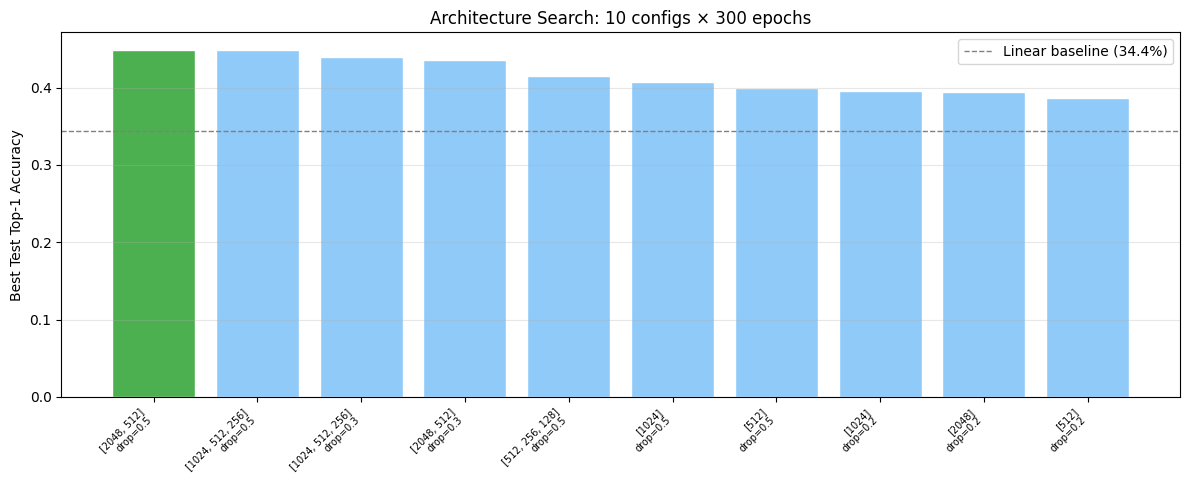


Best config:
  hidden_dims = [2048, 512]
  dropout_p   = 0.5
  best top-1  = 0.4491


In [ ]:
# Bar chart: best_test_top1 for each config
fig, ax = plt.subplots(figsize=(12, 5))

ranked = results_df.copy()
labels = [
    f"{row.hidden_dims}\ndrop={row.dropout_p}"
    for _, row in ranked.iterrows()
]
values = ranked["best_test_top1"].astype(float).values
colors = ["#4CAF50" if i == 0 else "#90CAF9" for i in range(len(values))]

bars = ax.bar(range(len(values)), values, color=colors, edgecolor="white")
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
ax.set_ylabel("Best Test Top-1 Accuracy")
ax.set_title(f"Architecture Search: {N_SEARCH_CONFIGS} configs × {SEARCH_EPOCHS} epochs")
ax.axhline(0.344, color="gray", linestyle="--", linewidth=1, label="Linear baseline (34.4%)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / "mlp_search_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the winner
best_row = results_df.iloc[0]
best_cfg = search_results[results_df.index[0] - 1]["_cfg"]
print(f"\nBest config:")
print(f"  hidden_dims = {best_cfg['hidden_dims']}")
print(f"  dropout_p   = {best_cfg['dropout_p']}")
print(f"  best top-1  = {float(best_row['best_test_top1']):.4f}")

## 8. Retrain Best Config (Full 1000 Epochs)

Use the full training budget with the winning configuration.
Scheduler patience is reset to the longer value used in `w7_mlp.ipynb`.

In [ ]:
# Override scheduler patience to full value for the final run
SCHEDULER_PATIENCE = 50

# Change this later
# best_cfg = {"hidden_dims": [1024], "dropout_p": 0.5, "batch_norm": True}
best_cfg = search_results[results_df.index[0] - 1]["_cfg"]
best_cfg['batch_norm'] = True # Add this key-value pair

print(f"Retraining best config for {FINAL_EPOCHS} epochs ...")
print(f"  hidden_dims = {best_cfg['hidden_dims']}")
print(f"  dropout_p   = {best_cfg['dropout_p']}")
print(f"  batch_norm  = {best_cfg['batch_norm']}")
print()

final_result = train_config(best_cfg, n_epochs=FINAL_EPOCHS, verbose=True)
final_model  = final_result["model"]
history      = final_result["history"]

print(f"\nFinal test top-1: {final_result['final_test_top1']:.4f}")
print(f"Best  test top-1: {final_result['best_test_top1']:.4f}")

Retraining best config for 1000 epochs ...
  hidden_dims = [2048, 512]
  dropout_p   = 0.5
  batch_norm  = True

  Epoch    1/1000 | train loss: 3.9593  train top-1: 0.277  test top-1: 0.122  lr: 1.00e-03
  Epoch   10/1000 | train loss: 0.1688  train top-1: 0.959  test top-1: 0.372  lr: 1.00e-03
  Epoch   20/1000 | train loss: 0.0346  train top-1: 0.991  test top-1: 0.401  lr: 1.00e-03
  Epoch   30/1000 | train loss: 0.0165  train top-1: 0.995  test top-1: 0.413  lr: 1.00e-03
  Epoch   40/1000 | train loss: 0.0104  train top-1: 0.996  test top-1: 0.418  lr: 1.00e-03
  Epoch   50/1000 | train loss: 0.0080  train top-1: 0.996  test top-1: 0.417  lr: 1.00e-03
  Epoch   60/1000 | train loss: 0.0080  train top-1: 0.996  test top-1: 0.423  lr: 1.00e-03
  Epoch   70/1000 | train loss: 0.0064  train top-1: 0.996  test top-1: 0.424  lr: 1.00e-03
  Epoch   80/1000 | train loss: 0.0050  train top-1: 0.997  test top-1: 0.426  lr: 1.00e-03
  Epoch   90/1000 | train loss: 0.0051  train top-1: 0.997 

## 9. Training Curves (Best Config)

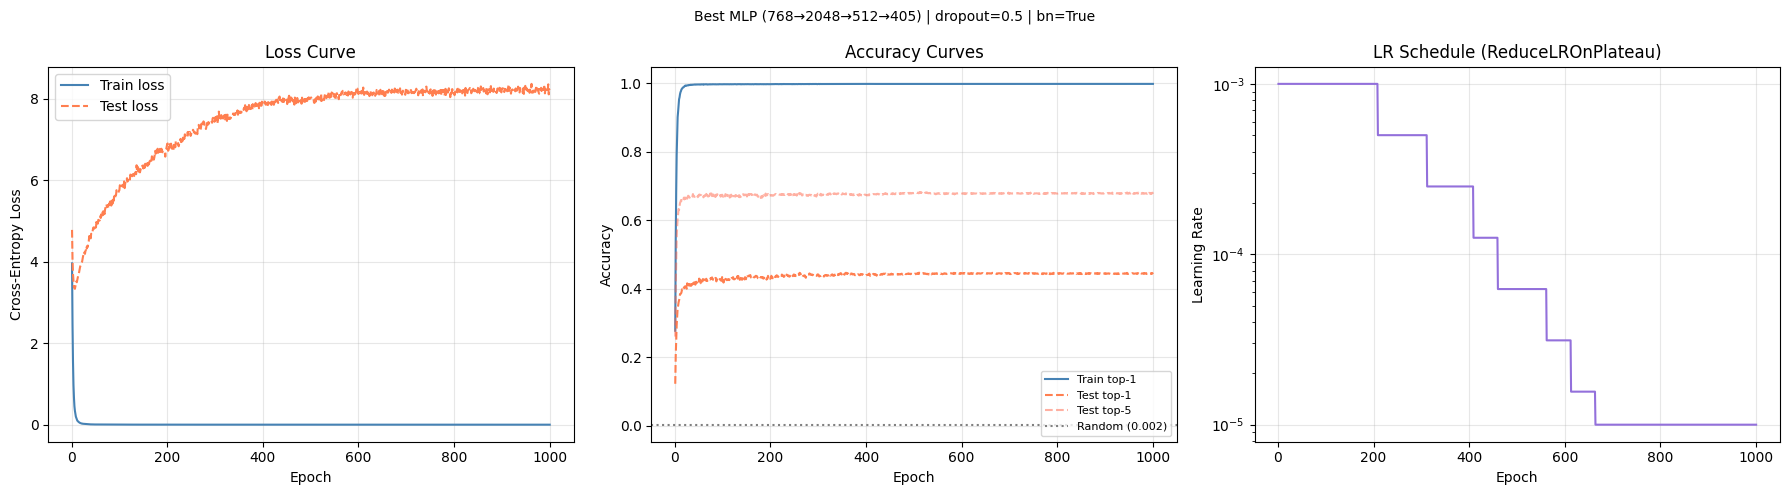

In [ ]:
epochs_range = range(1, FINAL_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(epochs_range, history["train_loss"], label="Train loss", color="steelblue")
ax.plot(epochs_range, history["test_loss"],  label="Test loss",  color="coral", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Loss Curve")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, history["train_top1"], label="Train top-1", color="steelblue")
ax.plot(epochs_range, history["test_top1"],  label="Test top-1",  color="coral", linestyle="--")
ax.plot(epochs_range, history["test_top5"],  label="Test top-5",  color="tomato", alpha=0.5, linestyle="--")
ax.axhline(1/n_classes, color="gray", linestyle=":", label=f"Random ({1/n_classes:.3f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(epochs_range, history["lr"], color="mediumpurple")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule (ReduceLROnPlateau)")
ax.set_yscale("log")
ax.grid(alpha=0.3)

arch_str = f"{d}→{'→'.join(str(h) for h in best_cfg['hidden_dims'])}→{n_classes}"
fig.suptitle(
    f"Best MLP ({arch_str}) | dropout={best_cfg['dropout_p']} | bn={best_cfg['batch_norm']}",
    fontsize=10
)
plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / "mlp_search_best_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Evaluation

### 10a. Final Metrics

In [ ]:
criterion_eval = nn.CrossEntropyLoss(weight=class_weights)
final_metrics = evaluate(final_model, test_loader, criterion_eval, DEVICE)
y_pred = final_metrics["preds"].numpy()
y_true = final_metrics["labels"].numpy()

print("=" * 60)
print("FINAL TEST RESULTS — Best Architecture from Search")
print("=" * 60)
print(f"  Architecture:    {arch_str}")
print(f"  Dropout:         {best_cfg['dropout_p']}")
print(f"  Batch Norm:      {best_cfg['batch_norm']}")
print(f"  Parameters:      {final_result['n_params']:,}")
print()
print(f"  Top-1 Accuracy:  {final_metrics['top1']:.4f}  ({final_metrics['top1']*100:.1f}%)")
print(f"  Top-5 Accuracy:  {final_metrics['top5']:.4f}  ({final_metrics['top5']*100:.1f}%)")
print(f"  Test Loss:       {final_metrics['loss']:.4f}")
print()
print(f"  Random baseline: {1/n_classes:.4f}  ({100/n_classes:.2f}%)")
print(f"  Linear baseline: 0.3440  (34.4%)")
print(f"  w7_mlp baseline: (see prior notebook)")
print("=" * 60)

FINAL TEST RESULTS — Best Architecture from Search
  Architecture:    768→2048→512→405
  Dropout:         0.5
  Batch Norm:      True
  Parameters:      2,836,885

  Top-1 Accuracy:  0.4422  (44.2%)
  Top-5 Accuracy:  0.6767  (67.7%)
  Test Loss:       8.2470

  Random baseline: 0.0025  (0.25%)
  Linear baseline: 0.3440  (34.4%)
  w7_mlp baseline: (see prior notebook)


### 10b. Per-Class Accuracy

In [ ]:
per_class_acc = {}
for class_idx, class_name in enumerate(le.classes_):
    mask = y_true == class_idx
    if mask.sum() == 0:
        continue
    per_class_acc[class_name] = (y_pred[mask] == class_idx).mean()

sorted_classes = sorted(per_class_acc.items(), key=lambda x: x[1], reverse=True)
accs_all = list(per_class_acc.values())

print(f"Median per-class accuracy:  {np.median(accs_all):.4f}")
print(f"Mean per-class accuracy:    {np.mean(accs_all):.4f}")
print(f"Classes with 100% accuracy: {sum(1 for v in accs_all if v == 1.0)}")
print(f"Classes with   0% accuracy: {sum(1 for v in accs_all if v == 0.0)}")
print("\nHardest pieces:")
for name, acc in sorted_classes[-10:]:
    print(f"  {name:<40} {acc:.2f}")

Median per-class accuracy:  0.3200
Mean per-class accuracy:    0.4165
Classes with 100% accuracy: 49
Classes with   0% accuracy: 114

Hardest pieces:
  bach__bwv64.2                            0.00
  bach__bwv64.4                            0.00
  bach__bwv69.6-a                          0.00
  bach__bwv83.5                            0.00
  bach__bwv86.6                            0.00
  bach__bwv87.7                            0.00
  bach__bwv89.6                            0.00
  bach__bwv9.7                             0.00
  bach__bwv90.5                            0.00
  bach__riemenschneider005                 0.00


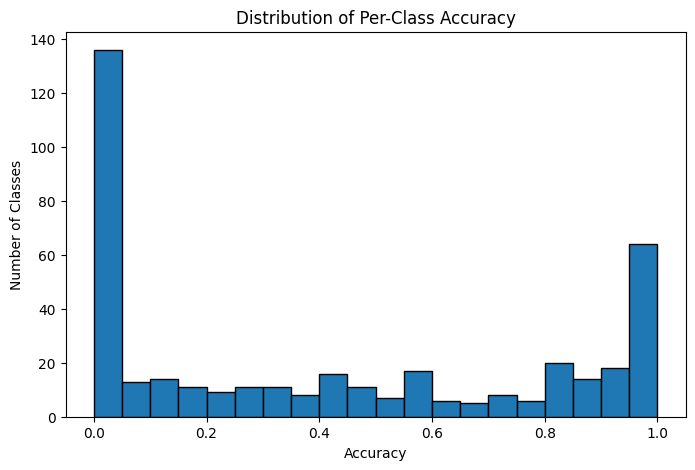

In [ ]:
# Adding this cell to visualize the per-class accuracy since it's like not exactly 0 or 100% anymore
plt.figure(figsize=(8, 5))
plt.hist(accs_all, bins=20, edgecolor='black')
plt.title("Distribution of Per-Class Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Number of Classes")
plt.show()

/tmp/ipykernel_4304/1165731762.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([n.split("__")[-1] for n in display_names], fontsize=8)


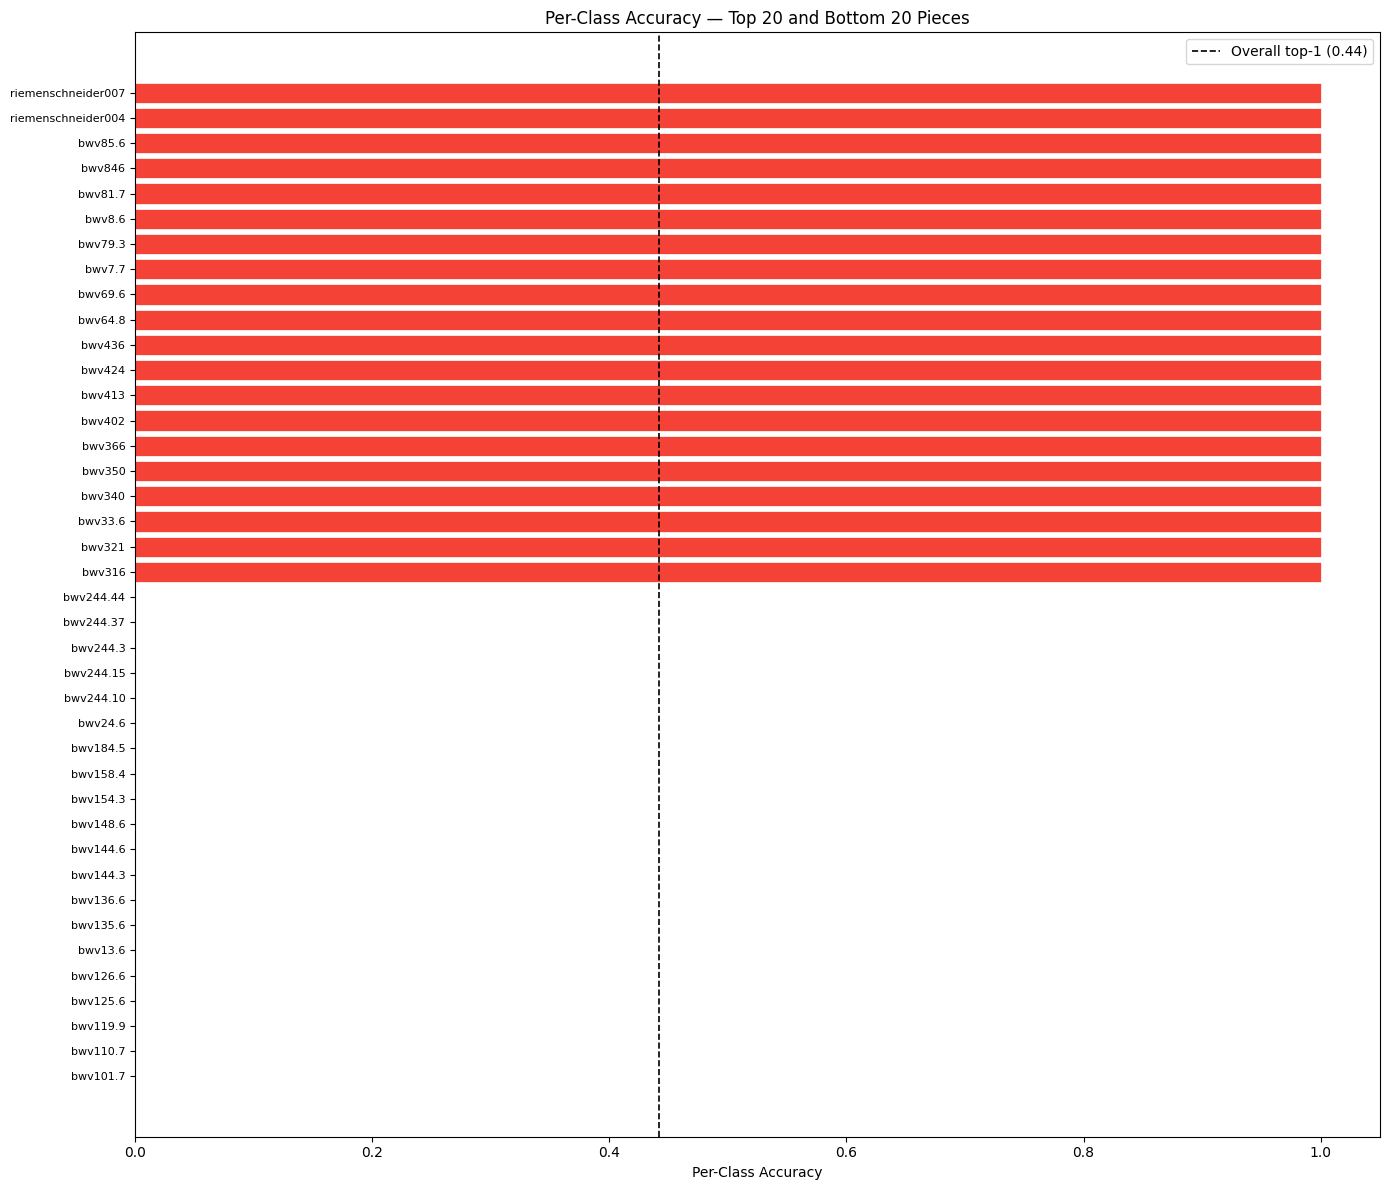

In [ ]:
names  = [c for c, _ in sorted_classes]
accs   = [a for _, a in sorted_classes]
n_show = min(TOP_N_CLASSES_CHART, len(sorted_classes))
half   = n_show // 2

display_names = names[:half] + names[-half:]
display_accs  = accs[:half]  + accs[-half:]
colors = ["#4CAF50"] * half + ["#F44336"] * half

fig, ax = plt.subplots(figsize=(14, max(6, n_show * 0.3)))
ax.barh(display_names, display_accs, color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(final_metrics["top1"], color="black", linestyle="--", linewidth=1.2,
           label=f"Overall top-1 ({final_metrics['top1']:.2f})")
ax.set_xlabel("Per-Class Accuracy")
ax.set_title(f"Per-Class Accuracy — Top {half} and Bottom {half} Pieces")
ax.set_xlim(0, 1.05)
ax.legend()
ax.set_yticklabels([n.split("__")[-1] for n in display_names], fontsize=8)
plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / "mlp_search_per_class_accuracy.png", dpi=150)
plt.show()

### 10c. Confusion Matrix

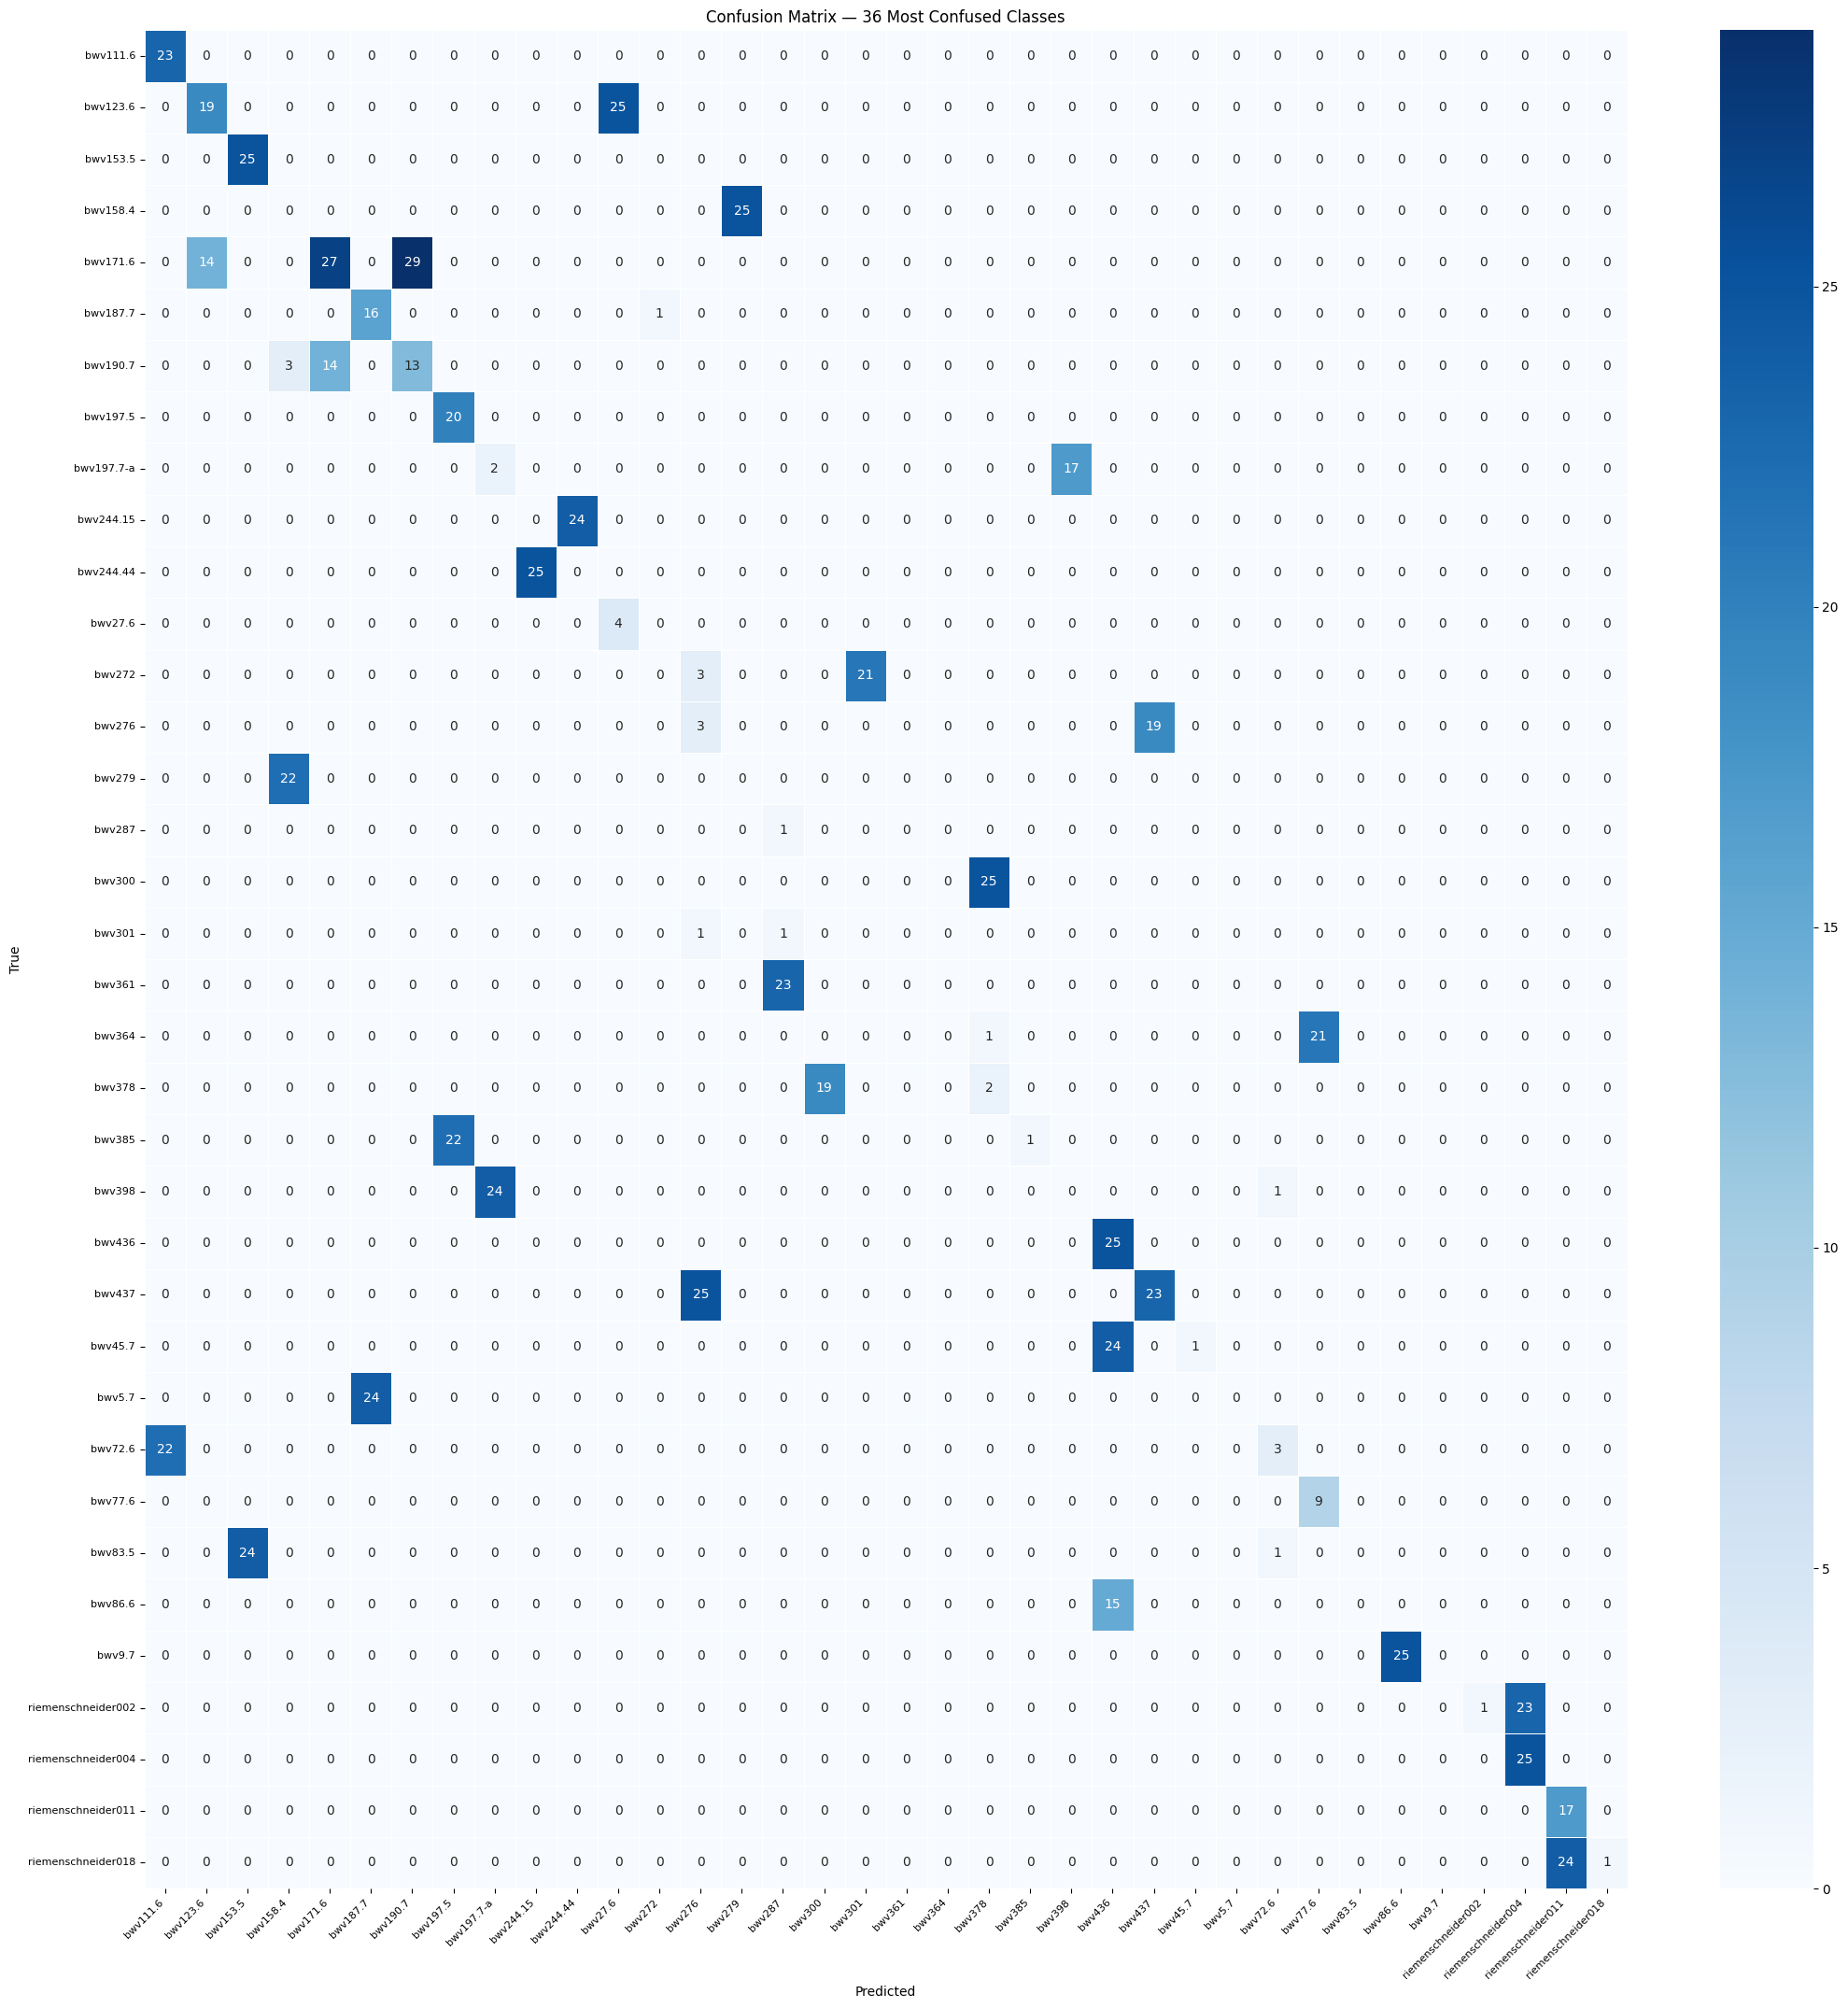

Top confused pairs (true → predicted, count):
  bwv171.6                       → bwv190.7                       (29 snippets)
  bwv300                         → bwv378                         (25 snippets)
  bwv158.4                       → bwv279                         (25 snippets)
  bwv437                         → bwv276                         (25 snippets)
  bwv9.7                         → bwv86.6                        (25 snippets)
  bwv123.6                       → bwv27.6                        (25 snippets)
  bwv244.44                      → bwv244.15                      (25 snippets)
  bwv244.15                      → bwv244.44                      (24 snippets)
  bwv83.5                        → bwv153.5                       (24 snippets)
  riemenschneider018             → riemenschneider011             (24 snippets)
  bwv45.7                        → bwv436                         (24 snippets)
  bwv5.7                         → bwv187.7                       (24 snip

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

flat_indices = np.argsort(cm_errors.ravel())[::-1][:TOP_N_CONFUSED]
top_true_idx, top_pred_idx = np.unravel_index(flat_indices, cm_errors.shape)

involved    = sorted(set(top_true_idx) | set(top_pred_idx))
sub_cm      = cm[np.ix_(involved, involved)]
names_short = [le.classes_[i].split("__")[-1] for i in involved]

fig, ax = plt.subplots(figsize=(max(10, len(involved) * 0.6),
                                max(8,  len(involved) * 0.6)))
sns.heatmap(sub_cm, xticklabels=names_short, yticklabels=names_short,
            annot=True, fmt="d", cmap="Blues", linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {len(involved)} Most Confused Classes")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(EMBEDDINGS_DIR / "mlp_search_confusion_matrix.png", dpi=150)
plt.show()

print("Top confused pairs (true → predicted, count):")
for ti, pi in zip(top_true_idx, top_pred_idx):
    count = cm[ti, pi]
    if count > 0:
        print(f"  {le.classes_[ti].split('__')[-1]:<30} → "
              f"{le.classes_[pi].split('__')[-1]:<30} ({count} snippets)")

## 11. Summary

In [ ]:
print("=" * 60)
print("ARCHITECTURE SEARCH SUMMARY")
print("=" * 60)
print(f"  Configs searched:  {N_SEARCH_CONFIGS} (random sample, seed={SEED})")
print(f"  Epochs per config: {SEARCH_EPOCHS}")
print()
print(f"  Best architecture:")
print(f"    hidden_dims = {best_cfg['hidden_dims']}")
print(f"    dropout_p   = {best_cfg['dropout_p']}")
print(f"    batch_norm  = {best_cfg['batch_norm']}")
print(f"    parameters  = {final_result['n_params']:,}")
print()
print(f"  Final results ({FINAL_EPOCHS} epochs):")
print(f"    Top-1 Accuracy:  {final_metrics['top1']:.4f}  ({final_metrics['top1']*100:.1f}%)")
print(f"    Top-5 Accuracy:  {final_metrics['top5']:.4f}  ({final_metrics['top5']*100:.1f}%)")
print(f"    Median per-class:{np.median(accs_all):.4f}")
print()
print(f"  Random baseline: {1/n_classes:.4f}  ({100/n_classes:.2f}%)")
print(f"  Linear baseline: 0.3440  (34.4%)")
print("=" * 60)

ARCHITECTURE SEARCH SUMMARY
  Configs searched:  10 (random sample, seed=42)
  Epochs per config: 300

  Best architecture:
    hidden_dims = [2048, 512]
    dropout_p   = 0.5
    batch_norm  = True
    parameters  = 2,836,885

  Final results (1000 epochs):
    Top-1 Accuracy:  0.4422  (44.2%)
    Top-5 Accuracy:  0.6767  (67.7%)
    Median per-class:0.3200

  Random baseline: 0.0025  (0.25%)
  Linear baseline: 0.3440  (34.4%)
